In [1]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


with open("df_recipes_reduced_ingredients.pkl", "rb") as f:
    df_recipes_reduced_ingredients = pickle.load(f)

with open("df_all_reviews.pkl", "rb") as f:
    df_all_reviews = pickle.load(f)

In [2]:
df_all_reviews.columns[:]

Index(['user_id', 'recipe_id', 'date', 'rating', 'review', 'name', 'minutes',
       'contributor_id', 'submitted', 'tags', 'n_steps', 'steps',
       'description', 'ingredients', 'n_ingredients', 'n_tags', 'calories',
       'fat', 'sugar', 'sodium', 'protein', 'saturated fat', 'carbohydrates'],
      dtype='object')

In [3]:
df_all_reviews_full = df_all_reviews.copy()

df_all_reviews = df_all_reviews_full.sample(n=10000, random_state=42)

# Klasifikacija nad recenzijama

In [4]:
df_all_reviews["high_rating"] = (df_all_reviews["rating"] >= 4.5).astype(int)

In [5]:
df_all_reviews["high_rating"].value_counts(normalize=True)

high_rating
1    0.7205
0    0.2795
Name: proportion, dtype: float64

In [6]:
num_cols_reviews = [
    "minutes","n_steps","n_ingredients","n_tags",
    "calories","fat","sugar","sodium","protein",
    "saturated fat","carbohydrates"
]

X_reviews = df_all_reviews[num_cols_reviews]
y_reviews = df_all_reviews["high_rating"]

In [7]:
X_text = df_all_reviews["review"]

Xr_train, Xr_test, X_text_train, X_text_test, yr_train, yr_test = train_test_split(
    X_reviews,
    X_text,
    y_reviews,
    test_size=0.3,
    random_state=42,
    stratify=y_reviews
)

print(Xr_train.shape, Xr_test.shape)
print(yr_train.shape, yr_test.shape)
print(X_text_train.shape, X_text_test.shape)

(7000, 11) (3000, 11)
(7000,) (3000,)
(7000,) (3000,)


In [8]:
Xr_train_nb = Xr_train.copy()
Xr_test_nb = Xr_test.copy()

scaler = StandardScaler()
Xr_train = scaler.fit_transform(Xr_train)
Xr_test = scaler.transform(Xr_test)

In [9]:
tfidf = TfidfVectorizer(max_features=500)

X_text_train = tfidf.fit_transform(X_text_train)
X_text_test = tfidf.transform(X_text_test)

In [10]:
from scipy.sparse import hstack

X_train_combined = hstack([X_text_train, Xr_train])
X_test_combined = hstack([X_text_test, Xr_test])

In [11]:
print(X_train_combined.shape)

(7000, 511)


Text(0.5, 1.0, 'Distribution of target variable')

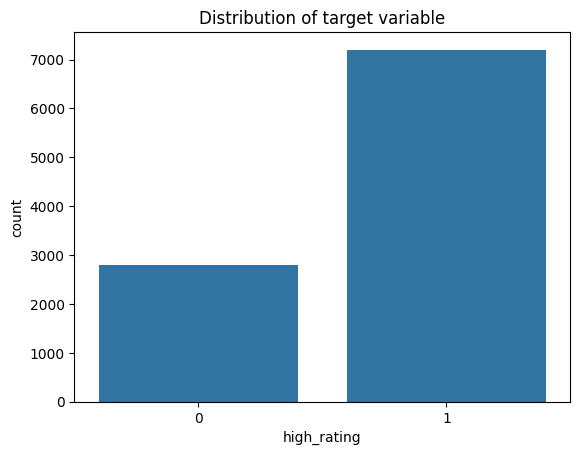

In [12]:
sns.countplot(x=y_reviews)
plt.title("Distribution of target variable")

# Random Forest

In [14]:
from sklearn.metrics import accuracy_score

results_rf = []

for n in [50, 100, 150]:
    
    rf_num = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        class_weight="balanced"
    )
    rf_num.fit(Xr_train, yr_train)
    y_pred_num = rf_num.predict(Xr_test)
    acc_num = accuracy_score(yr_test, y_pred_num)
    y_proba_num = rf_num.predict_proba(Xr_test)[:, 1]
    auc_num = roc_auc_score(yr_test, y_proba_num)

    
    rf_text = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        class_weight="balanced"
    )
    rf_text.fit(X_text_train, yr_train)
    y_pred_text = rf_text.predict(X_text_test)
    acc_text = accuracy_score(yr_test, y_pred_text)
    y_proba_text = rf_text.predict_proba(X_text_test)[:, 1]
    auc_text = roc_auc_score(yr_test, y_proba_text)
    
    
    rf_comb = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        class_weight="balanced"
    )
    rf_comb.fit(X_train_combined, yr_train)
    y_pred_comb = rf_comb.predict(X_test_combined)
    acc_comb = accuracy_score(yr_test, y_pred_comb)
    y_proba_comb = rf_comb.predict_proba(X_test_combined)[:, 1]
    auc_comb = roc_auc_score(yr_test, y_proba_comb)
    
    results_rf.append([n, acc_num, acc_text, acc_comb, auc_num, auc_text, auc_comb])

rf_df = pd.DataFrame(results_rf, columns=[
    "n_estimators", 
    "acc_num", "acc_text", "acc_comb",
    "auc_num", "auc_text", "auc_comb"
])
print(rf_df)

   n_estimators   acc_num  acc_text  acc_comb   auc_num  auc_text  auc_comb
0            50  0.690000  0.766667  0.760667  0.514609  0.757648  0.756689
1           100  0.692667  0.767333  0.764333  0.526491  0.768150  0.763480
2           150  0.692000  0.770333  0.759667  0.525580  0.769942  0.767336


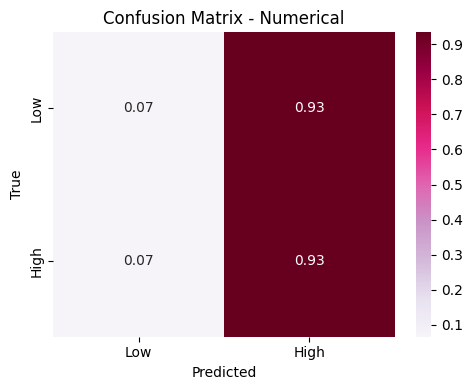

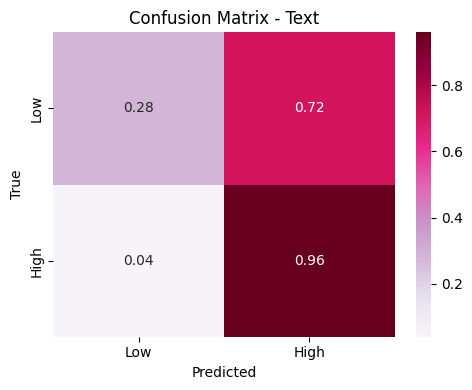

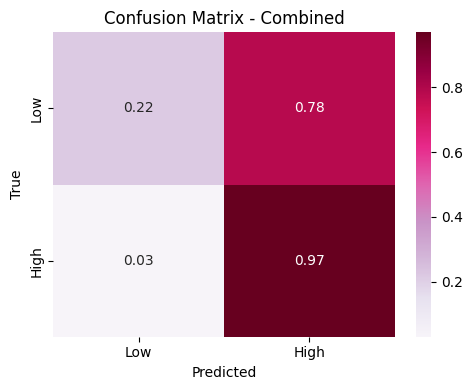

In [15]:
preds = [
    ("Numerical", y_pred_num),
    ("Text", y_pred_text),
    ("Combined", y_pred_comb)
]

for name, y_pred in preds:
    
    cm = confusion_matrix(yr_test, y_pred, normalize='true')
    
    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="PuRd",
        xticklabels=["Low", "High"],
        yticklabels=["Low", "High"]
    )
    
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    
    plt.tight_layout()
    plt.show()

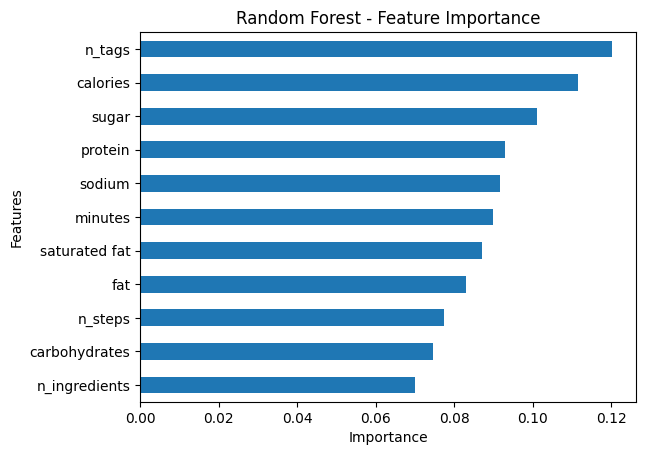

In [16]:
importances = rf_num.feature_importances_
feature_importance = pd.Series(importances, index=X_reviews.columns)
feature_importance = feature_importance.sort_values(ascending=True)

plt.figure()
feature_importance.plot(kind='barh')
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest - Feature Importance")
plt.show()

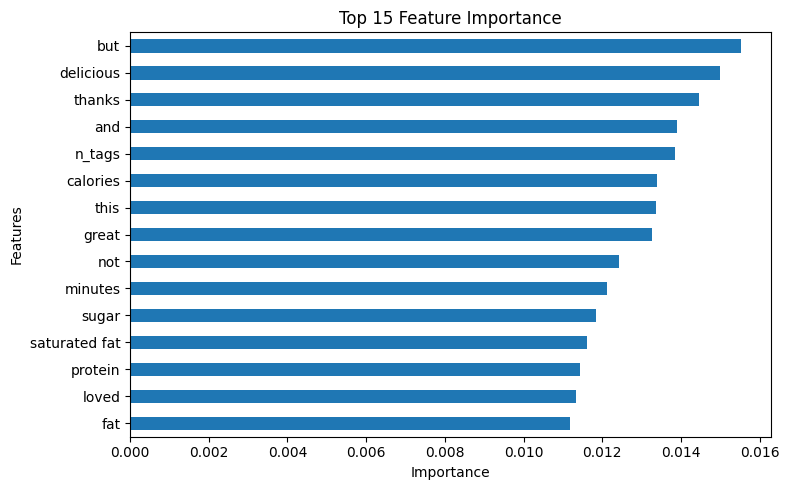

In [24]:
importances = rf_comb.feature_importances_

feature_names = list(tfidf.get_feature_names_out()) + list(X_reviews.columns)

feature_importance = pd.Series(importances, index=feature_names)
feature_importance = feature_importance.sort_values(ascending=True)
top_n = 15

top_features = feature_importance.sort_values(ascending=False).head(top_n)

plt.figure(figsize=(8,5))
top_features.sort_values().plot(kind='barh')

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 15 Feature Importance")
plt.tight_layout()
plt.show()

# Gradient Boosting Classifier

In [20]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

results_gb = []

for n in [50, 100, 150]:
    
    gb_num = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    gb_num.fit(Xr_train, yr_train)
    y_pred_num = gb_num.predict(Xr_test)
    acc_num = accuracy_score(yr_test, y_pred_num)
    y_proba_num = gb_num.predict_proba(Xr_test)[:, 1]
    auc_num = roc_auc_score(yr_test, y_proba_num)
    
    
    gb_text = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    gb_text.fit(X_text_train, yr_train)
    y_pred_text = gb_text.predict(X_text_test)
    acc_text = accuracy_score(yr_test, y_pred_text)
    y_proba_text = gb_text.predict_proba(X_text_test)[:, 1]
    auc_text = roc_auc_score(yr_test, y_proba_text)
    
    gb_comb = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    gb_comb.fit(X_train_combined, yr_train)
    y_pred_comb = gb_comb.predict(X_test_combined)
    acc_comb = accuracy_score(yr_test, y_pred_comb)
    y_proba_comb = gb_comb.predict_proba(X_test_combined)[:, 1]
    auc_comb = roc_auc_score(yr_test, y_proba_comb)
    
    
    results_gb.append([n, acc_num, acc_text, acc_comb, auc_num, auc_text, auc_comb])

gb_df = pd.DataFrame(results_gb, columns=[
    "n_estimators",
    "acc_num", "acc_text", "acc_comb",
    "auc_num", "auc_text", "auc_comb"
])
print(gb_df)

   n_estimators   acc_num  acc_text  acc_comb   auc_num  auc_text  auc_comb
0            50  0.720000  0.754667  0.758667  0.507472  0.757556  0.756199
1           100  0.718000  0.769667  0.771333  0.513110  0.769175  0.770941
2           150  0.716667  0.769000  0.774000  0.521968  0.773890  0.773174


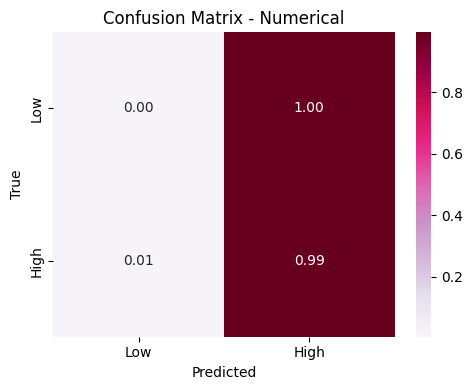

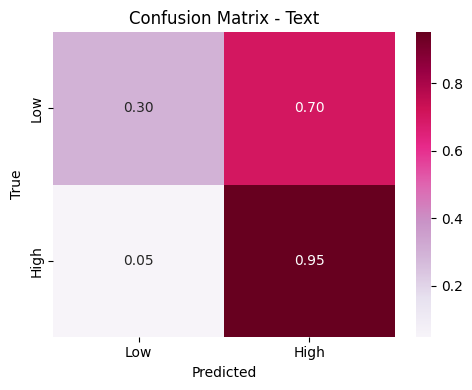

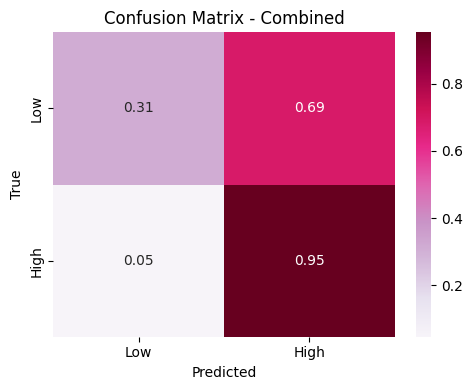

In [21]:
preds = [
    ("Numerical", y_pred_num),
    ("Text", y_pred_text),
    ("Combined", y_pred_comb)
]

for name, y_pred in preds:
    
    cm = confusion_matrix(yr_test, y_pred, normalize='true')
    
    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="PuRd",
        xticklabels=["Low", "High"],
        yticklabels=["Low", "High"]
    )
    
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    
    plt.tight_layout()
    plt.show()

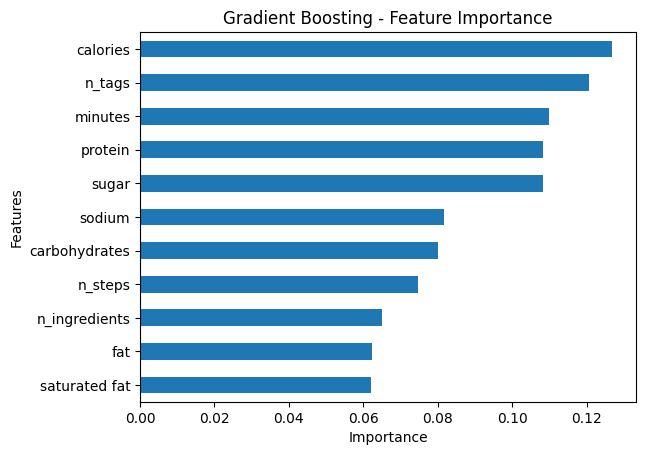

In [22]:
importances = gb_num.feature_importances_

feature_importance = pd.Series(importances, index=X_reviews.columns)
feature_importance = feature_importance.sort_values()

feature_importance.plot(kind='barh')
plt.title("Gradient Boosting - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

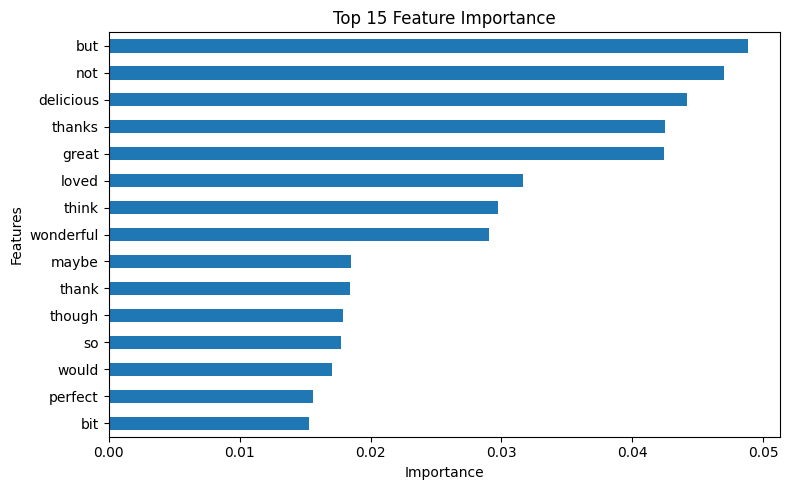

In [25]:
importances = gb_comb.feature_importances_

feature_names = list(tfidf.get_feature_names_out()) + list(X_reviews.columns)

feature_importance = pd.Series(importances, index=feature_names)
feature_importance = feature_importance.sort_values(ascending=True)
top_n = 15

top_features = feature_importance.sort_values(ascending=False).head(top_n)

plt.figure(figsize=(8,5))
top_features.sort_values().plot(kind='barh')

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 15 Feature Importance")
plt.tight_layout()
plt.show()

# Logistic Regression

In [26]:
import warnings
warnings.filterwarnings("ignore")

results_lr = []

for c in [0.1, 1, 10]: 
    
    lr_num = LogisticRegression(
        C=c,
        max_iter=3000
    )
    lr_num.fit(Xr_train, yr_train)
    y_pred_num = lr_num.predict(Xr_test)
    acc_num = accuracy_score(yr_test, y_pred_num)
    y_proba_num = lr_num.predict_proba(Xr_test)[:, 1]
    auc_num = roc_auc_score(yr_test, y_proba_num)
    
    
    lr_text = LogisticRegression(
        C=c,
        max_iter=3000
    )
    lr_text.fit(X_text_train, yr_train)
    y_pred_text = lr_text.predict(X_text_test)
    acc_text = accuracy_score(yr_test, y_pred_text)
    y_proba_text = lr_text.predict_proba(X_text_test)[:, 1]
    auc_text = roc_auc_score(yr_test, y_proba_text)
    
    lr_comb = LogisticRegression(
        C=c,
        max_iter=3000
    )
    lr_comb.fit(X_train_combined, yr_train)
    y_pred_comb = lr_comb.predict(X_test_combined)
    acc_comb = accuracy_score(yr_test, y_pred_comb)
    y_proba_comb = lr_comb.predict_proba(X_test_combined)[:, 1]
    auc_comb = roc_auc_score(yr_test, y_proba_comb)
    
    results_lr.append([c, acc_num, acc_text, acc_comb, auc_num, auc_text, auc_comb])

lr_df = pd.DataFrame(results_lr, columns=[
    "C",
    "acc_num", "acc_text", "acc_comb",
    "auc_num", "auc_text", "auc_comb"
])
print(lr_df)

      C   acc_num  acc_text  acc_comb   auc_num  auc_text  auc_comb
0   0.1  0.720667     0.746  0.743333  0.536048  0.765496  0.764829
1   1.0  0.720333     0.777  0.775000  0.535117  0.777274  0.777809
2  10.0  0.720333     0.772  0.771000  0.534791  0.773996  0.774489


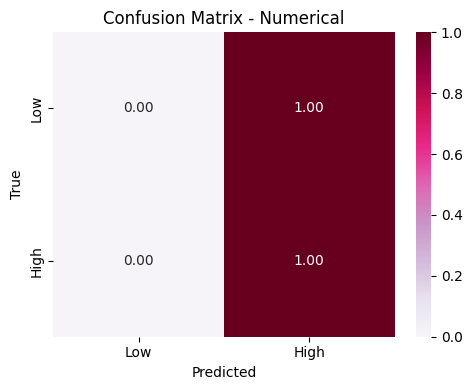

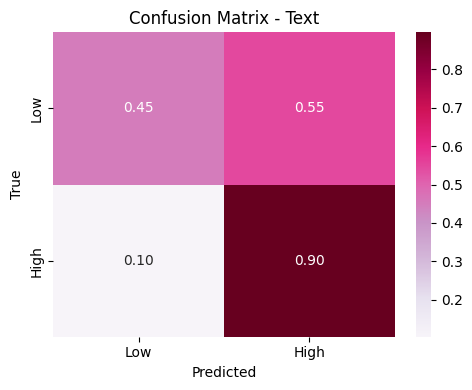

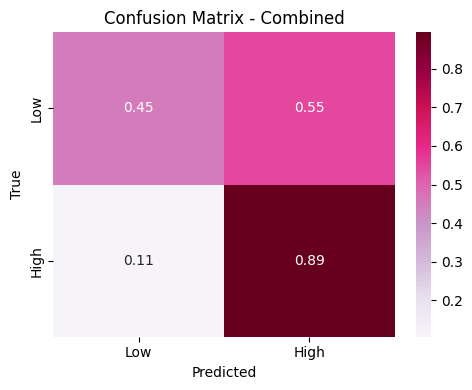

In [27]:
preds = [
    ("Numerical", y_pred_num),
    ("Text", y_pred_text),
    ("Combined", y_pred_comb)
]

for name, y_pred in preds:
    
    cm = confusion_matrix(yr_test, y_pred, normalize='true')
    
    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="PuRd",
        xticklabels=["Low", "High"],
        yticklabels=["Low", "High"]
    )
    
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    
    plt.tight_layout()
    plt.show()

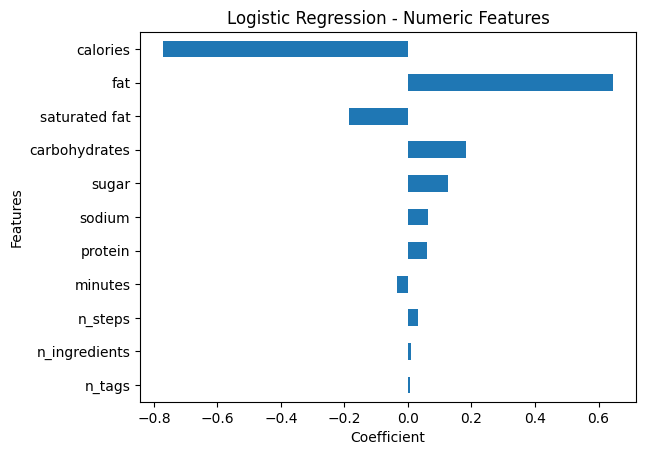

In [34]:
importances = lr_num.coef_[0]

feature_importance = pd.Series(importances, index=X_reviews.columns)
feature_importance = feature_importance.reindex(
    feature_importance.abs().sort_values().index
)

feature_importance.plot(kind='barh')

plt.title("Logistic Regression - Numeric Features")
plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.show()

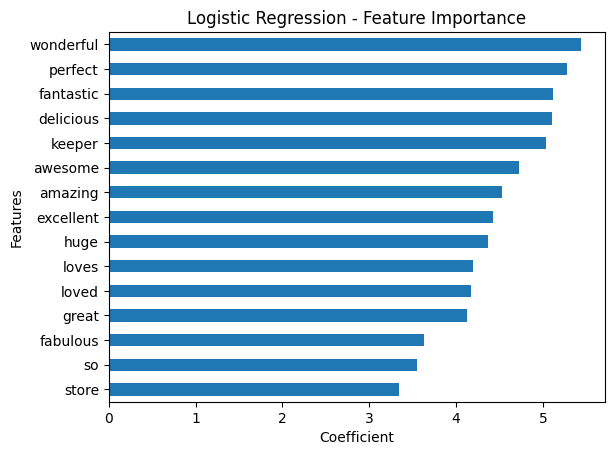

In [35]:
importances = lr_comb.coef_[0]

feature_names = list(tfidf.get_feature_names_out()) + list(X_reviews.columns)

feature_importance = pd.Series(importances, index=feature_names)
feature_importance = feature_importance.sort_values()

feature_importance.tail(15).plot(kind='barh')

plt.title("Logistic Regression - Feature Importance")
plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.show()

# KNN

In [36]:

results_knn = []

for k in [3, 5, 7]:
    
    knn_num = KNeighborsClassifier(n_neighbors=k)
    knn_num.fit(Xr_train, yr_train)
    y_pred_num = knn_num.predict(Xr_test)
    acc_num = accuracy_score(yr_test, y_pred_num)
    
    y_proba_num = knn_num.predict_proba(Xr_test)[:, 1]
    auc_num = roc_auc_score(yr_test, y_proba_num)
    
    
    knn_text = KNeighborsClassifier(n_neighbors=k)
    knn_text.fit(X_text_train, yr_train)
    y_pred_text = knn_text.predict(X_text_test)
    acc_text = accuracy_score(yr_test, y_pred_text)
    
    y_proba_text = knn_text.predict_proba(X_text_test)[:, 1]
    auc_text = roc_auc_score(yr_test, y_proba_text)
    
    
    knn_comb = KNeighborsClassifier(n_neighbors=k)
    knn_comb.fit(X_train_combined, yr_train)
    y_pred_comb = knn_comb.predict(X_test_combined)
    acc_comb = accuracy_score(yr_test, y_pred_comb)
    y_proba_comb = knn_comb.predict_proba(X_test_combined)[:, 1]
    auc_comb = roc_auc_score(yr_test, y_proba_comb)
    
    
    results_knn.append([k, acc_num, acc_text, acc_comb, auc_num, auc_text, auc_comb])

knn_df = pd.DataFrame(results_knn, columns=[
    "k",
    "acc_num", "acc_text", "acc_comb",
    "auc_num", "auc_text", "auc_comb"
])
print(knn_df)

   k   acc_num  acc_text  acc_comb   auc_num  auc_text  auc_comb
0  3  0.657333  0.537333  0.641000  0.519722  0.522390  0.527387
1  5  0.674000  0.522000  0.675333  0.515125  0.525345  0.529985
2  7  0.684667  0.506667  0.685333  0.515948  0.517045  0.539984


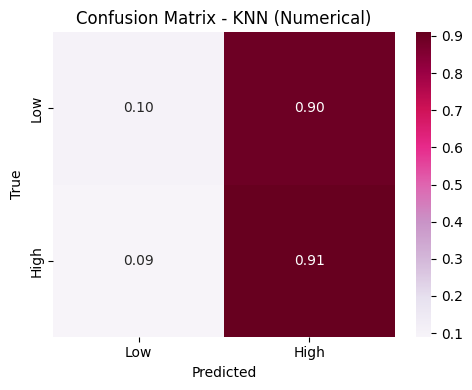

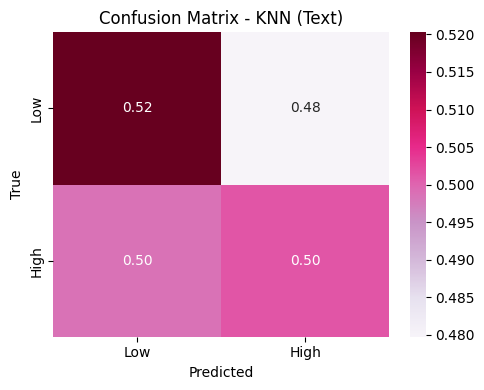

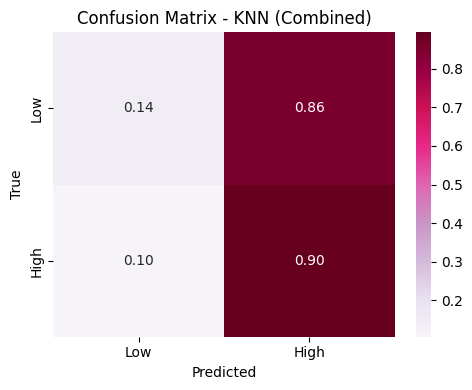

In [37]:
preds = [
    ("Numerical", y_pred_num),
    ("Text", y_pred_text),
    ("Combined", y_pred_comb)
]

for name, y_pred in preds:
    
    cm = confusion_matrix(yr_test, y_pred, normalize='true')
    
    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="PuRd",
        xticklabels=["Low", "High"],
        yticklabels=["Low", "High"]
    )
    
    plt.title(f"Confusion Matrix - KNN ({name})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    
    plt.tight_layout()
    plt.show()

# NB

In [13]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, roc_auc_score

nb_num = GaussianNB()
nb_num.fit(Xr_train_nb, yr_train)
y_pred_num = nb_num.predict(Xr_test_nb)
acc_num = accuracy_score(yr_test, y_pred_num)

y_proba_num = nb_num.predict_proba(Xr_test_nb)[:, 1]
auc_num = roc_auc_score(yr_test, y_proba_num)


nb_text = MultinomialNB()
nb_text.fit(X_text_train, yr_train)
y_pred_text = nb_text.predict(X_text_test)
acc_text = accuracy_score(yr_test, y_pred_text)

y_proba_text = nb_text.predict_proba(X_text_test)[:, 1]
auc_text = roc_auc_score(yr_test, y_proba_text)

from scipy.sparse import hstack

X_train_combined_nb = hstack([X_text_train, Xr_train_nb])
X_test_combined_nb = hstack([X_text_test, Xr_test_nb])

nb_comb = MultinomialNB()
nb_comb.fit(X_train_combined_nb, yr_train)
y_pred_comb = nb_comb.predict(X_test_combined_nb)
acc_comb = accuracy_score(yr_test, y_pred_comb)

y_proba_comb = nb_comb.predict_proba(X_test_combined_nb)[:, 1]
auc_comb = roc_auc_score(yr_test, y_proba_comb)


nb_df = pd.DataFrame({
    "Model": ["NB_num", "NB_text", "NB_combined"],
    "Accuracy": [acc_num, acc_text, acc_comb],
    "AUC": [auc_num, auc_text, auc_comb]
})

print(nb_df)

         Model  Accuracy       AUC
0       NB_num  0.695667  0.522739
1      NB_text  0.737667  0.759771
2  NB_combined  0.614667  0.560056


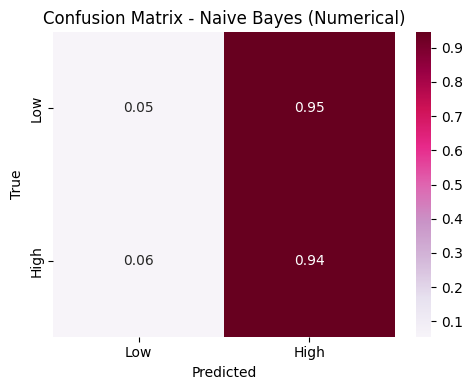

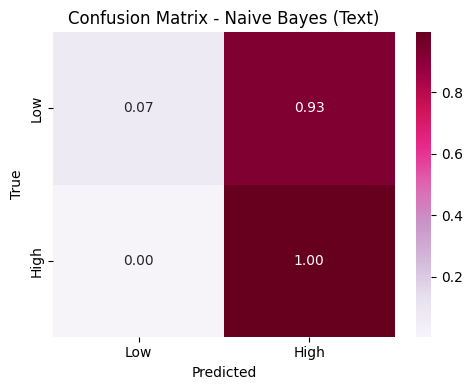

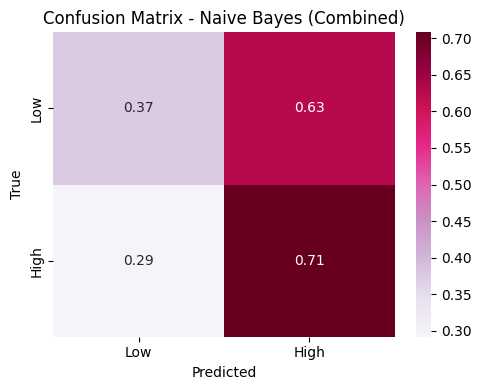

In [14]:
preds = [
    ("Numerical", y_pred_num),
    ("Text", y_pred_text),
    ("Combined", y_pred_comb)
]

for name, y_pred in preds:
    
    cm = confusion_matrix(yr_test, y_pred, normalize='true')
    
    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="PuRd",
        xticklabels=["Low", "High"],
        yticklabels=["Low", "High"]
    )
    
    plt.title(f"Confusion Matrix - Naive Bayes ({name})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    
    plt.tight_layout()
    plt.show()

# Final Results

In [15]:
final_results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "Logistic Regression", "KNN", "Naive Bayes"],
    
    "Numerical": [0.6933, 0.7200, 0.7203, 0.6867, 0.6957],
    "Text": [0.7703, 0.7690, 0.7770, 0.5373, 0.7377],
    "Combined": [0.7643, 0.7740, 0.7617, 0.6883, 0.6147]
})

final_results.style \
    .background_gradient(cmap="BuPu") \
    .highlight_max(axis=0, color="#ffcce6") \
    .highlight_min(axis=0, color="#cce6ff") \
    .set_properties(**{
        'border': '1px solid #ddd',
        'text-align': 'center',
        'font-size': '12pt'
    }) \
    .set_caption("Model Performance Comparison") \
    .format({
        "Numerical": "{:.3f}",
        "Text": "{:.3f}",
        "Combined": "{:.3f}"
    })

,Model,Numerical,Text,Combined
0,Random Forest,0.693,0.770,0.764
1,Gradient Boosting,0.720,0.769,0.774
2,Logistic Regression,0.720,0.777,0.762
3,KNN,0.687,0.537,0.688
4,Naive Bayes,0.696,0.738,0.615


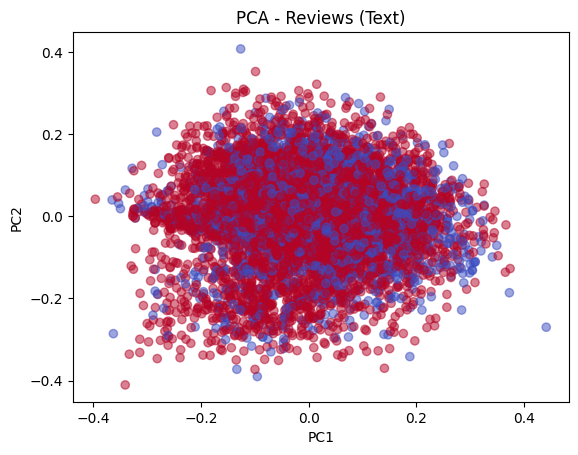

In [18]:
X_pca = PCA(n_components=2).fit_transform(X_text_train.toarray())

plt.scatter(X_pca[:,0], X_pca[:,1], c=yr_train, cmap="coolwarm", alpha=0.5)
plt.title("PCA - Reviews (Text)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Klasifikacija nad receptima

In [19]:
df_recipes_reduced_ingredients = df_recipes_reduced_ingredients.sample(
    n=10000,
    random_state=42
)

In [20]:
df_recipes_reduced_ingredients["high_rating"] = (
    df_recipes_reduced_ingredients["avg_rating"] >= 4.5
).astype(int)

In [21]:
df_recipes_reduced_ingredients.columns[:]

Index(['recipe_id', 'name', 'description_x', 'avg_rating', 'num_ratings',
       'calories', 'fat', 'sugar', 'sodium', 'protein', 'saturated fat',
       'carbohydrates', 'ingredients', 'n_ingredients', 'minutes',
       'contributor_id', 'submitted', 'tags', 'n_steps', 'steps',
       'description_y', 'ingredients_list', 'ing_all-purpose flour',
       'ing_baking powder', 'ing_baking soda', 'ing_black pepper',
       'ing_brown sugar', 'ing_butter', 'ing_cinnamon', 'ing_egg', 'ing_eggs',
       'ing_flour', 'ing_garlic', 'ing_garlic cloves', 'ing_lemon juice',
       'ing_milk', 'ing_olive oil', 'ing_onion', 'ing_parmesan cheese',
       'ing_pepper', 'ing_salt', 'ing_salt and pepper', 'ing_sugar',
       'ing_vanilla', 'ing_vegetable oil', 'ing_water', 'high_rating'],
      dtype='object')

In [22]:
X = df_recipes_reduced_ingredients.select_dtypes(include="number").drop(
    columns=["avg_rating", "high_rating"],
    errors="ignore"
)

y = df_recipes_reduced_ingredients["high_rating"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [27]:
import warnings
warnings.filterwarnings("ignore")

X_train_nb = X_train.copy()
X_test_nb = X_test.copy()

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7000, 37), (3000, 37), (7000,), (3000,))

# Random Forest

In [30]:
from sklearn.metrics import accuracy_score, roc_auc_score

results_rf = []

for n in [50, 100, 150]:
    
    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=10,
        random_state=42,
        class_weight="balanced"
    )
    
    rf.fit(X_train, y_train)
    
    y_pred_test = rf.predict(X_test)
    
    acc_test = accuracy_score(y_test, y_pred_test)
    
    roc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
    
    results_rf.append([n, acc_test, roc])

rf_df = pd.DataFrame(results_rf, columns=["n_estimators", "test_acc", "roc_auc"])

print(rf_df)

   n_estimators  test_acc   roc_auc
0            50  0.580333  0.551698
1           100  0.590000  0.550794
2           150  0.594000  0.555716


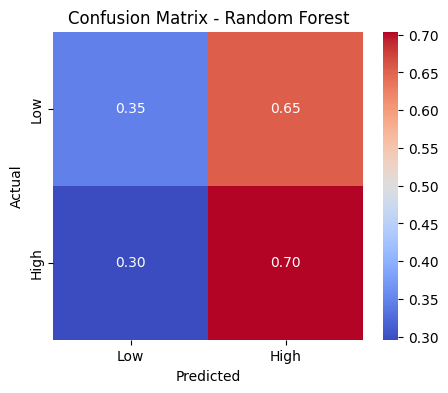

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels=["Low", "High"],
    yticklabels=["Low", "High"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

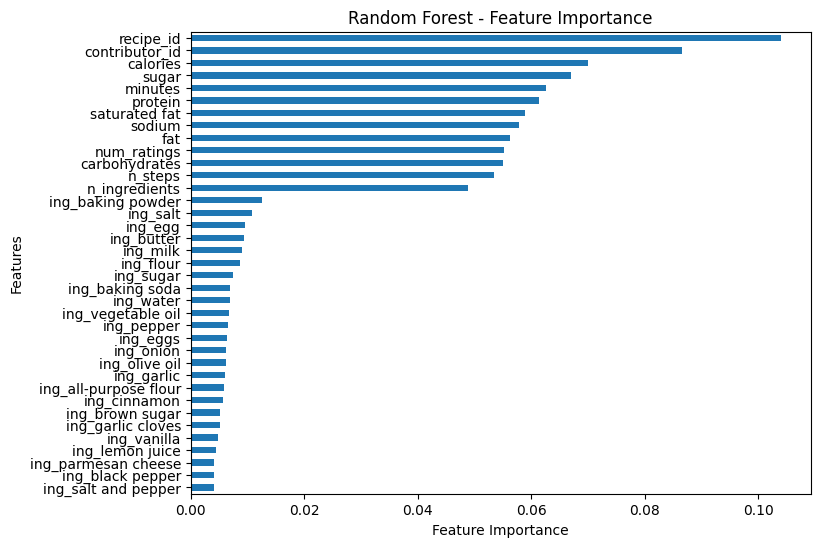

In [32]:
importances = rf.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=True)

plt.figure(figsize=(8,6))
feature_importance.plot(kind='barh')

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest - Feature Importance")

plt.show()

# Gradient Boosting

In [33]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

results_gb = []

for n in [50, 100, 150]:
    
    gb = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    
    gb.fit(X_train, y_train)
    
    y_pred_test = gb.predict(X_test)
    
    acc_test = accuracy_score(y_test, y_pred_test)
    
    roc = roc_auc_score(y_test, gb.predict_proba(X_test)[:,1])
    
    results_gb.append([n, acc_test, roc])

gb_df = pd.DataFrame(results_gb, columns=["n_estimators",  "test_acc", "roc_auc"])
print(gb_df)

   n_estimators  test_acc   roc_auc
0            50  0.629667  0.561152
1           100  0.624667  0.558123
2           150  0.623667  0.555080


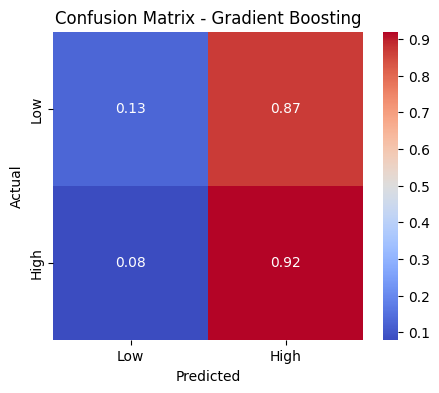

In [34]:
from sklearn.metrics import confusion_matrix

y_pred = gb.predict(X_test)

cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels=["Low", "High"],
    yticklabels=["Low", "High"]
)

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.49      0.13      0.21      1125
           1       0.64      0.92      0.75      1875

    accuracy                           0.62      3000
   macro avg       0.57      0.52      0.48      3000
weighted avg       0.58      0.62      0.55      3000



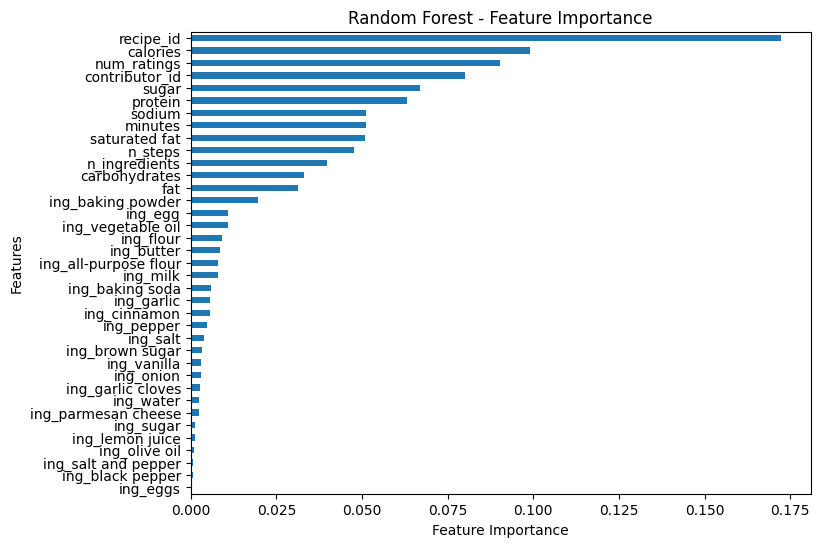

In [37]:
importances = gb.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=True)

plt.figure(figsize=(8,6))
feature_importance.plot(kind='barh')

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest - Feature Importance")

plt.show()

# Logistic Regression

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

results_lr = []

for c in [0.1, 1, 10]:
    
    lr = LogisticRegression(
        C=c,
        max_iter=3000,
        class_weight="balanced"
    )
    
    lr.fit(X_train, y_train)
    
    y_pred_test = lr.predict(X_test)
    
    acc_test = accuracy_score(y_test, y_pred_test)
    
    roc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])
    
    results_lr.append([c, acc_test, roc])

lr_df = pd.DataFrame(results_lr, columns=["C", "test_acc", "roc_auc"])
print(lr_df)

      C  test_acc   roc_auc
0   0.1  0.539000  0.549925
1   1.0  0.539667  0.550524
2  10.0  0.539333  0.550765


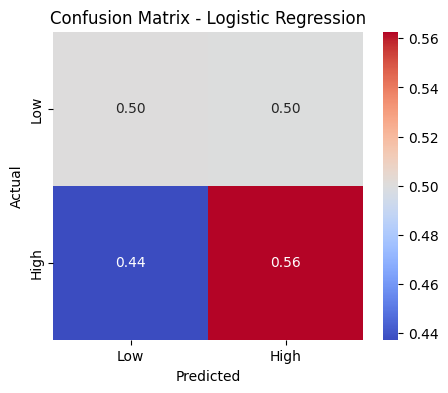

In [39]:
from sklearn.metrics import confusion_matrix

y_pred = lr.predict(X_test)

cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels=["Low", "High"],
    yticklabels=["Low", "High"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.41      0.50      0.45      1125
           1       0.65      0.56      0.60      1875

    accuracy                           0.54      3000
   macro avg       0.53      0.53      0.53      3000
weighted avg       0.56      0.54      0.55      3000



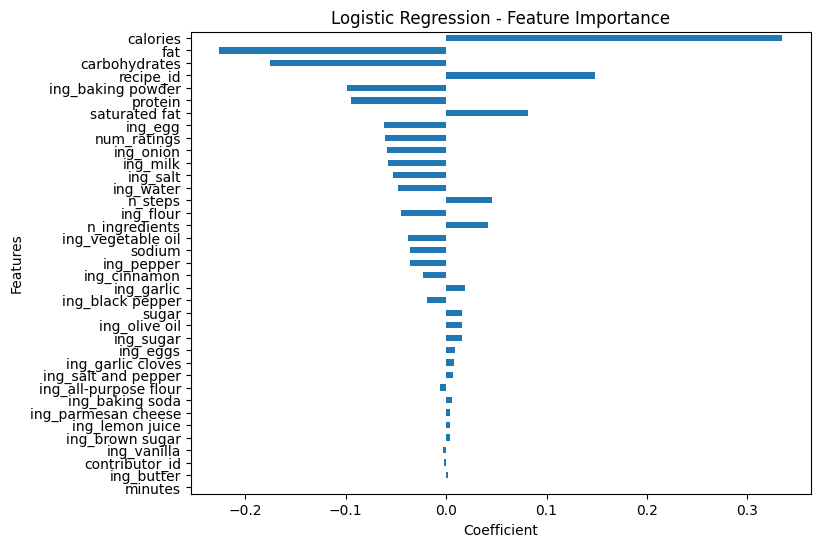

In [41]:
importances = lr.coef_[0]

feature_importance = pd.Series(importances, index=X.columns)

feature_importance = feature_importance.reindex(
    feature_importance.abs().sort_values().index
)

plt.figure(figsize=(8,6))
feature_importance.plot(kind='barh')

plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.title("Logistic Regression - Feature Importance")

plt.show()

# KNN

In [42]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

results_knn = []

for k in [3, 5, 7]:
    
    knn = KNeighborsClassifier(n_neighbors=k)
    
    knn.fit(X_train, y_train)
    
    y_pred_test = knn.predict(X_test)
    
    acc_test = accuracy_score(y_test, y_pred_test)
    
    roc = roc_auc_score(y_test, knn.predict_proba(X_test)[:,1])
    
    results_knn.append([k, acc_test, roc])

knn_df = pd.DataFrame(results_knn, columns=["k", "test_acc", "roc_auc"])
print(knn_df)

   k  test_acc   roc_auc
0  3  0.553333  0.510758
1  5  0.564333  0.522672
2  7  0.572333  0.526306


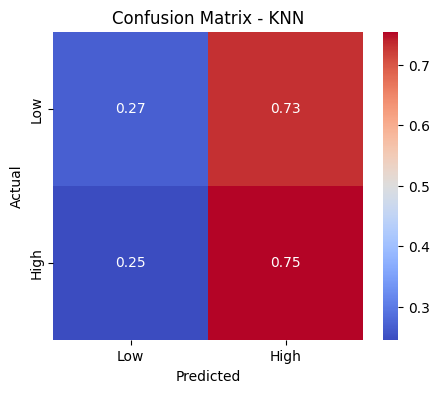

In [43]:
from sklearn.metrics import confusion_matrix

y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels=["Low", "High"],
    yticklabels=["Low", "High"]
)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [44]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.40      0.27      0.32      1125
           1       0.63      0.75      0.69      1875

    accuracy                           0.57      3000
   macro avg       0.51      0.51      0.50      3000
weighted avg       0.54      0.57      0.55      3000



# NB

In [45]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, roc_auc_score

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_test = nb.predict(X_test)

acc_test = accuracy_score(y_test, y_pred_test)

roc = roc_auc_score(y_test, nb.predict_proba(X_test)[:,1])

print("Test accuracy:", acc_test)
print("ROC-AUC:", roc)

Test accuracy: 0.574
ROC-AUC: 0.5249147259259259


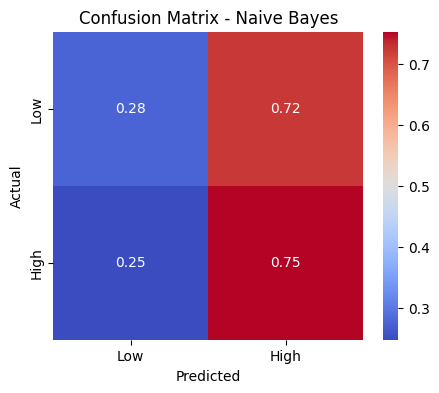

In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test, normalize='true')

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels=["Low", "High"],
    yticklabels=["Low", "High"]
)

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

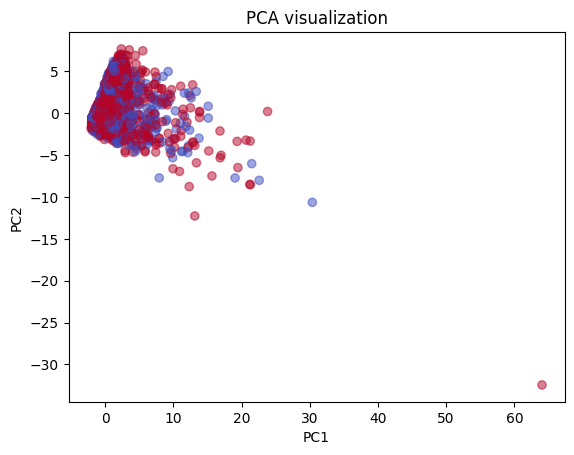

In [47]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap="coolwarm", alpha=0.5)
plt.title("PCA visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [49]:
final_results_2 = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "Logistic Regression",
        "KNN",
        "Naive Bayes"
    ],
    
    "Accuracy": [
        0.594,   
        0.60,    
        0.54,    
        0.57,    
        0.58     
    ],
    
    "ROC-AUC": [
        0.556,   
        0.56,    
        0.57,    
        0.53,    
        0.52     
    ]
})
final_results_2.style \
    .background_gradient(cmap="RdYlGn") \
    .highlight_max(axis=0, color="#90EE90") \
    .highlight_min(axis=0, color="#FFCCCB") \
    .set_properties(**{'text-align': 'center'}) \
    .format({
        "Accuracy": "{:.3f}",
        "ROC-AUC": "{:.3f}"
    }) \
    .set_caption("Model Comparison - Ingredient Dataset")

,Model,Accuracy,ROC-AUC
0,Random Forest,0.594,0.556
1,Gradient Boosting,0.600,0.560
2,Logistic Regression,0.540,0.570
3,KNN,0.570,0.530
4,Naive Bayes,0.580,0.520


In [50]:
comparison = pd.DataFrame({
    "Dataset": ["Reviews (Text)", "Ingredients (Numeric)"],
    "Accuracy": [0.77, 0.59],
    "ROC-AUC": [0.77, 0.56]
})

comparison.style \
    .background_gradient(cmap="RdYlGn") \
    .format({
        "Accuracy": "{:.2f}",
        "ROC-AUC": "{:.2f}"
    }) \
    .set_caption("Random Forest Comparison: Reviews vs Ingredients")

,Dataset,Accuracy,ROC-AUC
0,Reviews (Text),0.77,0.77
1,Ingredients (Numeric),0.59,0.56


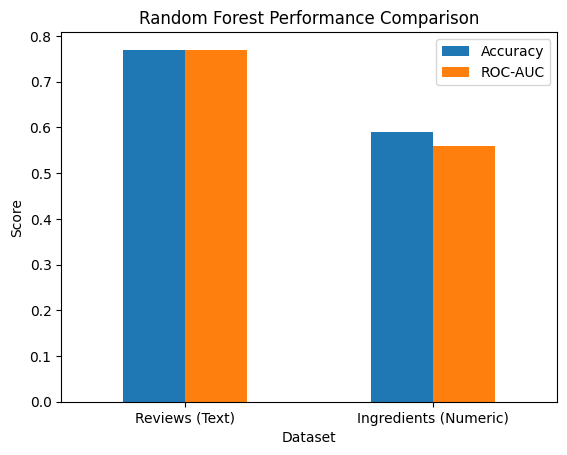

In [51]:
import matplotlib.pyplot as plt

comparison.set_index("Dataset").plot(kind="bar")

plt.title("Random Forest Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [52]:
comparison_gb = pd.DataFrame({
    "Dataset": ["Reviews (Text)", "Ingredients (Numeric)"],
    "Accuracy": [0.77, 0.62],  
    "ROC-AUC": [0.77, 0.56]
})

comparison_gb.style \
    .background_gradient(cmap="RdYlGn") \
    .format({
        "Accuracy": "{:.2f}",
        "ROC-AUC": "{:.2f}"
    }) \
    .set_caption("Gradient Boosting Comparison: Reviews vs Ingredients")

,Dataset,Accuracy,ROC-AUC
0,Reviews (Text),0.77,0.77
1,Ingredients (Numeric),0.62,0.56


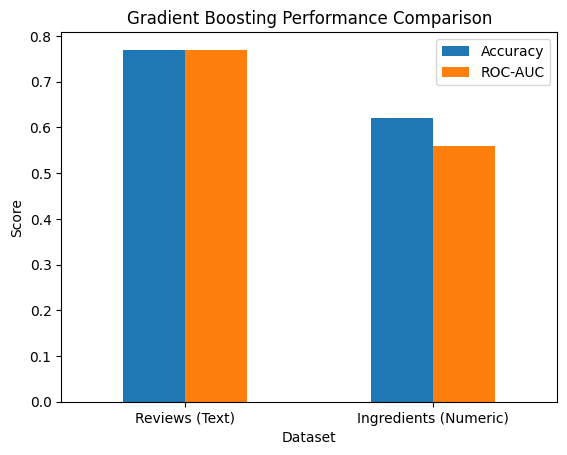

In [53]:
comparison_gb.set_index("Dataset").plot(kind="bar")
plt.title("Gradient Boosting Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [54]:
comparison_lr = pd.DataFrame({
    "Dataset": ["Reviews (Text)", "Ingredients (Numeric)"],
    "Accuracy": [0.78, 0.54],
    "ROC-AUC": [0.78, 0.55]
})

comparison_lr.style \
    .background_gradient(cmap="RdYlGn") \
    .format({
        "Accuracy": "{:.2f}",
        "ROC-AUC": "{:.2f}"
    }) \
    .set_caption("Logistic Regression Comparison: Reviews vs Ingredients")

,Dataset,Accuracy,ROC-AUC
0,Reviews (Text),0.78,0.78
1,Ingredients (Numeric),0.54,0.55


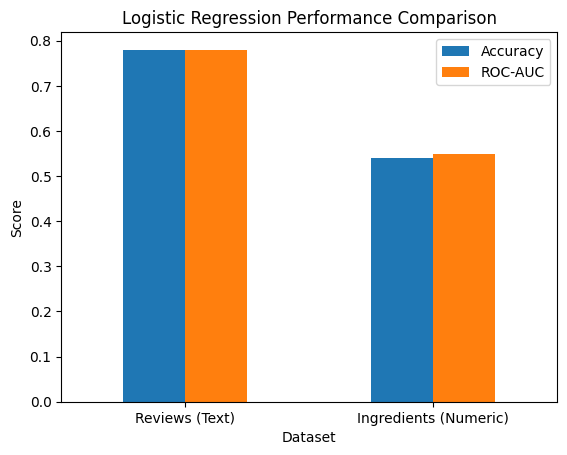

In [55]:
comparison_lr.set_index("Dataset").plot(kind="bar")
plt.title("Logistic Regression Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [56]:
comparison_knn = pd.DataFrame({
    "Dataset": ["Reviews (Comb)", "Ingredients (Numeric)"],
    "Accuracy": [0.68, 0.57],
    "ROC-AUC": [0.68, 0.55]
})

comparison_knn.style \
    .background_gradient(cmap="RdYlGn") \
    .format({
        "Accuracy": "{:.2f}",
        "ROC-AUC": "{:.2f}"
    }) \
    .set_caption("KNN Comparison: Reviews vs Ingredients")

,Dataset,Accuracy,ROC-AUC
0,Reviews (Comb),0.68,0.68
1,Ingredients (Numeric),0.57,0.55


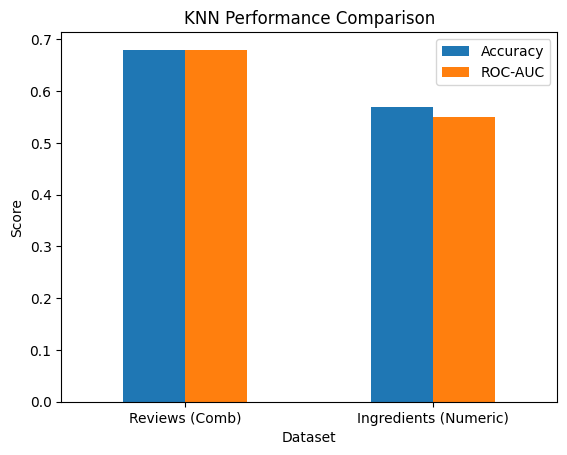

In [57]:
comparison_knn.set_index("Dataset").plot(kind="bar")
plt.title("KNN Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [58]:
comparison_nb = pd.DataFrame({
    "Dataset": ["Reviews (Text)", "Ingredients (Numeric)"],
    "Accuracy": [0.74, 0.58],
    "ROC-AUC": [0.76, 0.52]
})

comparison_nb.style \
    .background_gradient(cmap="RdYlGn") \
    .format({
        "Accuracy": "{:.2f}",
        "ROC-AUC": "{:.2f}"
    }) \
    .set_caption("Naive Bayes Comparison: Reviews vs Ingredients")

,Dataset,Accuracy,ROC-AUC
0,Reviews (Text),0.74,0.76
1,Ingredients (Numeric),0.58,0.52


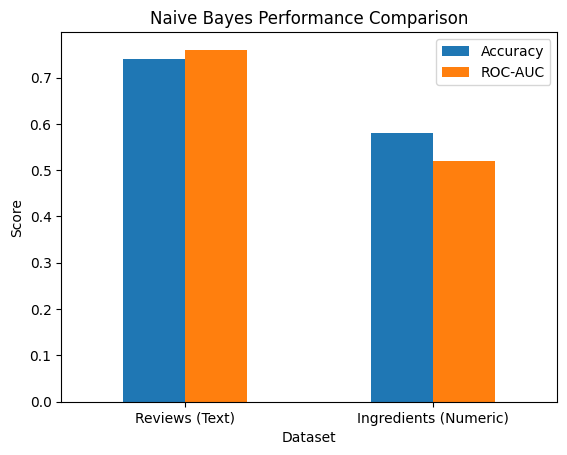

In [59]:
comparison_nb.set_index("Dataset").plot(kind="bar")
plt.title("Naive Bayes Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [60]:
final_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "Logistic Regression",
        "KNN",
        "Naive Bayes"
    ],
    
    "Reviews Accuracy": [
        0.77,
        0.77,
        0.77,
        0.68,
        0.74
    ],
    
    "Reviews ROC-AUC": [
        0.77,
        0.77,
        0.77,
        0.68,
        0.74
    ],
    
    "Ingredients Accuracy": [
        0.59,
        0.60,
        0.59,
        0.57,
        0.58
    ],
    
    "Ingredients ROC-AUC": [
        0.56,
        0.56,
        0.57,
        0.55,
        0.56
    ]
})

final_comparison.style \
    .background_gradient(cmap="RdYlGn", subset=[
        "Reviews Accuracy", "Reviews ROC-AUC",
        "Ingredients Accuracy", "Ingredients ROC-AUC"
    ]) \
    .highlight_max(axis=0, color="#90EE90") \
    .highlight_min(axis=0, color="#FFCCCB") \
    .format({
        "Reviews Accuracy": "{:.2f}",
        "Reviews ROC-AUC": "{:.2f}",
        "Ingredients Accuracy": "{:.2f}",
        "Ingredients ROC-AUC": "{:.2f}"
    }) \
    .set_caption("Final Model Comparison: Reviews vs Ingredients")

,Model,Reviews Accuracy,Reviews ROC-AUC,Ingredients Accuracy,Ingredients ROC-AUC
0,Random Forest,0.77,0.77,0.59,0.56
1,Gradient Boosting,0.77,0.77,0.60,0.56
2,Logistic Regression,0.77,0.77,0.59,0.57
3,KNN,0.68,0.68,0.57,0.55
4,Naive Bayes,0.74,0.74,0.58,0.56


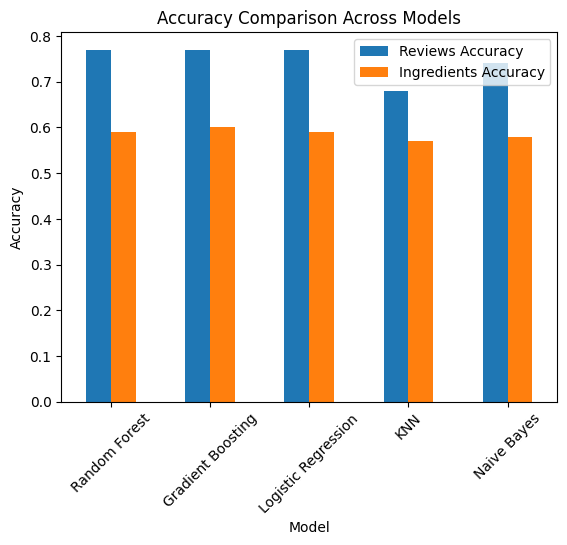

In [61]:
final_comparison.set_index("Model")[[
    "Reviews Accuracy",
    "Ingredients Accuracy"
]].plot(kind="bar")

plt.title("Accuracy Comparison Across Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()